# Synthetic dataset generation and screening workflow

This notebook demonstrates the complete workflow in the manuscript pseudocode using one depth point from a real labeled sample (four receiver traces, 128 samples per trace). Intermediate results are shown at every stage.

**Input:** the `SAMPLE_ID`-th 64-depth sliding-window sample in `raw_data/` (the local development layout `output_72_depths/raw_data/` is also supported).  
**Output:** global temporal translation, differential moveout simulation, the first physical screening step, Syn_1--Syn_4 augmentation, the second $\delta_{\max}$ screening step, and the final retention decision.

The released notebook embeds the exact core functions and parameter dictionaries extracted from the production scripts. It therefore runs with only this notebook and the released `raw_data/` directory. Required packages are `numpy`, `pandas`, `matplotlib`, `scipy`, `PyWavelets`, `tqdm`, and `psutil`.

After running the notebook, change the sample index, depth index, translation settings, or $\delta_{\max}$ to inspect how the four traces and their first-arrival picks change through the workflow.

## Workflow

1. Load one 64-depth sample and select the four receiver traces at one depth point.
2. Apply Global Temporal Translation and Differential Moveout Simulation.
3. Merge the candidates and perform the first screening using adjacent inter-receiver arrival-time differences.
4. Apply the four Syn_1--Syn_4 augmentation configurations.
5. Apply the final $\delta_{\max}$ screening and summarize the retained results.

> The batch pipeline screens complete 64-depth windows. The figures focus on the selected depth point, while the tables also report the screening result for the complete window.

In [46]:
from __future__ import annotations
from pathlib import Path
import random
import sys
import types
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

SEED = 42
SAMPLE_ID = 0
DEPTH_INDEX = 31
GLOBAL_DIRECTION = "right"   # "left" or "right"
GLOBAL_SHIFT_AMOUNT = 8      # integer samples; real script ranges: left 1-47, right 1-40
MOVEOUT_DIRECTION = "right"  # "left" or "right"
MOVEOUT_STEP = 2             # real script ranges: left 1-7, right 1-12
DELTA_MAX = 12.0

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False,
                     "axes.spines.right": False})

def find_data_directory():
    for start in [Path.cwd(), *Path.cwd().parents]:
        if (start / "raw_data" / "inputs").exists():
            return start, start / "raw_data"
        if (start / "output_72_depths" / "raw_data").exists():
            return start, start / "output_72_depths" / "raw_data"
    raise FileNotFoundError(
        "Cannot locate raw_data/. Place raw_data next to this notebook."
    )

ROOT, DATA_DIR = find_data_directory()

print("Input dataset:", DATA_DIR.relative_to(ROOT))

Input dataset: raw_data


## Embedded production code

The following cells contain the exact constants and core functions extracted from the production scripts used to generate the synthetic dataset. They are embedded so that this public notebook does not depend on unreleased external Python files.

In [47]:
# Exact core implementation extracted from dif_time_g1.py.
global_script = types.ModuleType("global_script")
exec(compile('import numpy as np\n\nimport os\n\nimport logging\n\nfrom pathlib import Path\n\nfrom tqdm import tqdm\n\nimport shutil\n\nimport pywt\n\nfrom scipy.signal import hilbert\n\nimport random\n\nimport multiprocessing as mp\n\nfrom functools import partial\n\nimport gc\n\nimport psutil\n\nSIGNAL_PARAMS = {\n    \'sampling_rate\': 125000,  # 采样率（Hz）\n    \'wavelet_name\': \'cmor1.5-1.0\',  # 小波基函数\n    \'wavelet_scales\': np.arange(1, 32),  # 小波尺度范围\n    \'decomposition_level\': 5,  # 小波分解层数\n    \'harmonic_params\': {\n        \'num_harmonics\': 5,    # 谐波数量\n        \'weight\': 0.3,         # 谐波贡献权重\n        \'decay_rate\': 1.5      # 谐波衰减率\n    },\n    \'smoothing_params\': {\n        \'new_value_weight\': 0.7,   # 新值权重\n        \'history_weight\': 0.3,     # 历史值权重\n        \'window_size\': 15          # 平滑窗口大小\n    },\n    \'phase_correction\': np.pi/8    # 相位修正值\n}\n\ndef vectorized_analyze_time_frequency(signals, params):\n    """使用CWT对一批信号进行时频分析 (向量化版本)"""\n    # pywt.cwt不支持对多行直接操作，需要循环，但可以先收集结果再处理\n    main_freqs = []\n    for signal in signals:\n        coefficients, frequencies = pywt.cwt(\n            signal,\n            params[\'wavelet_scales\'],\n            params[\'wavelet_name\'],\n            1/params[\'sampling_rate\']\n        )\n        power = np.abs(coefficients) ** 2\n        mean_power = np.mean(power, axis=1)\n        main_freq_idx = np.argmax(mean_power)\n        main_freqs.append(frequencies[main_freq_idx])\n    return np.array(main_freqs)\n\ndef vectorized_shift_waveform_left(waveforms, shift_amount):\n    """向左移动一批波形 (向量化版本)\n    Args:\n        waveforms: 波形数据，形状为(N, 128)\n        shift_amount: 左移量\n    Returns:\n        shifted_waveforms: 左移后的波形\n    """\n    num_waveforms, signal_length = waveforms.shape\n    shifted_waveforms = np.zeros_like(waveforms)\n    shifted_waveforms[:, :-shift_amount] = waveforms[:, shift_amount:]\n\n    main_freqs = vectorized_analyze_time_frequency(waveforms, SIGNAL_PARAMS)\n    \n    analytic_signal = hilbert(waveforms, axis=1)\n    inst_phase = np.angle(analytic_signal) + SIGNAL_PARAMS[\'phase_correction\']\n    end_phases = inst_phase[:, -1]\n\n    t_original_end = (signal_length - 1) / SIGNAL_PARAMS[\'sampling_rate\']\n    t_new = np.arange(shift_amount) / SIGNAL_PARAMS[\'sampling_rate\'] + t_original_end\n\n    for i in range(shift_amount):\n        new_phases = end_phases + 2 * np.pi * main_freqs * (t_new[i] - t_original_end)\n        \n        base_values = np.mean(np.abs(waveforms[:, -SIGNAL_PARAMS[\'smoothing_params\'][\'window_size\']:]), axis=1)\n        base_signals = base_values * np.cos(new_phases)\n        \n        # --- 向量化谐波计算 ---\n        j_values = np.arange(1, SIGNAL_PARAMS[\'harmonic_params\'][\'num_harmonics\'] + 1)\n        decay = 1 / (j_values ** SIGNAL_PARAMS[\'harmonic_params\'][\'decay_rate\'])\n        \n        # 使用广播机制来计算所有谐波分量\n        # new_phases: (num_waveforms,) -> (num_waveforms, 1)\n        # j_values + 1: (num_harmonics,)\n        # harmonic_phase: (num_waveforms, num_harmonics)\n        harmonic_phase = new_phases[:, np.newaxis] * (j_values + 1)\n        \n        # base_values: (num_waveforms,) -> (num_waveforms, 1)\n        # decay: (num_harmonics,)\n        # harmonic_contributions: (num_waveforms, num_harmonics)\n        harmonic_contributions = decay * base_values[:, np.newaxis] * np.cos(harmonic_phase)\n        \n        # 对所有谐波分量求和\n        harmonic_values = np.sum(harmonic_contributions, axis=1)\n        # --- 谐波计算结束 ---\n            \n        new_values = base_signals + harmonic_values * SIGNAL_PARAMS[\'harmonic_params\'][\'weight\']\n        \n        if i > 0:\n            new_values = (SIGNAL_PARAMS[\'smoothing_params\'][\'new_value_weight\'] * new_values +\n                          SIGNAL_PARAMS[\'smoothing_params\'][\'history_weight\'] * \n                          shifted_waveforms[:, -shift_amount + i - 1])\n                          \n        shifted_waveforms[:, -shift_amount + i] = new_values\n\n    return shifted_waveforms\n\ndef vectorized_shift_waveform_right(waveforms, shift_amount):\n    """向右移动一批波形 (向量化版本)"""\n    shifted_waveforms = np.zeros_like(waveforms)\n    shifted_waveforms[:, shift_amount:] = waveforms[:, :-shift_amount]\n    return shifted_waveforms', "<embedded:dif_time_g1.py>", "exec"), global_script.__dict__)
print("Loaded embedded production core: dif_time_g1.py")

Loaded embedded production core: dif_time_g1.py


In [48]:
# Exact core implementation extracted from diff_velocity_g1.py.
moveout_script = types.ModuleType("moveout_script")
exec(compile('import os\n\nimport numpy as np\n\nfrom scipy import interpolate\n\nimport shutil\n\nimport pywt\n\nfrom scipy.signal import hilbert, resample\n\nimport matplotlib.pyplot as plt\n\nimport random\n\nimport multiprocessing as mp\n\nfrom pathlib import Path\n\nfrom tqdm import tqdm\n\nimport psutil\n\nSIGNAL_PARAMS = {\n    \'sampling_rate\': 125000,  # 原始采样率（Hz）\n    \'interp_sampling_rate\': 250000,  # 插值后的采样率（Hz）\n    \'wavelet_name\': \'cmor1.5-1.0\',  # 小波基函数\n    \'wavelet_scales\': np.arange(1, 32),  # 小波尺度范围\n    \'decomposition_level\': 5,  # 小波分解层数\n    \'harmonic_params\': {\n        \'num_harmonics\': 5,    # 谐波数量\n        \'weight\': 0.3,         # 谐波贡献权重\n        \'decay_rate\': 1.5      # 谐波衰减率\n    },\n    \'smoothing_params\': {\n        \'new_value_weight\': 0.7,   # 新值权重\n        \'history_weight\': 0.3,     # 历史值权重\n        \'window_size\': 15          # 平滑窗口大小\n    },\n    \'phase_correction\': np.pi/8,   # 相位修正值\n    \'interp_factor\': 2,            # 插值因子（101 -> 201）\n    \'final_length\': 128            # 最终波形长度\n}\n\ndef analyze_time_frequency(signal, params, is_interpolated=False):\n    """使用连续小波变换进行时频分析"""\n    # 根据信号是否已插值选择合适的采样率\n    sampling_rate = params[\'interp_sampling_rate\'] if is_interpolated else params[\'sampling_rate\']\n    \n    # 执行连续小波变换\n    coefficients, frequencies = pywt.cwt(\n        signal,\n        params[\'wavelet_scales\'],\n        params[\'wavelet_name\'],\n        1/sampling_rate\n    )\n    \n    # 计算时频能量谱\n    power = np.abs(coefficients) ** 2\n    \n    # 找出主要频率分量\n    mean_power = np.mean(power, axis=1)\n    main_freq_idx = np.argmax(mean_power)\n    main_freq = frequencies[main_freq_idx]\n    \n    return coefficients, frequencies, power, main_freq\n\ndef get_instantaneous_phase(signal, main_freq, params):\n    """计算信号的瞬时相位"""\n    # 使用希尔伯特变换获取解析信号\n    analytic_signal = hilbert(signal)\n    \n    # 计算瞬时相位\n    instantaneous_phase = np.angle(analytic_signal)\n    \n    # 应用相位修正\n    instantaneous_phase += params[\'phase_correction\']\n    \n    return instantaneous_phase\n\ndef interpolate_signal(signal, factor=2):\n    """对信号进行插值，扩展采样点数量"""\n    # 创建原始信号的x坐标\n    x_original = np.arange(len(signal))\n    \n    # 创建插值后的x坐标\n    x_interp = np.linspace(0, len(signal) - 1, len(signal) * factor)\n    \n    # 使用线性插值\n    f = interpolate.interp1d(x_original, signal, kind=\'linear\')\n    \n    # 计算插值后的信号\n    signal_interp = f(x_interp)\n    \n    return signal_interp\n\ndef extend_right_with_wavelet(signal, num_points, main_freq, params):\n    """使用小波变换和相位信息向右延伸信号"""\n    # 获取瞬时相位\n    inst_phase = get_instantaneous_phase(signal, main_freq, params)\n    end_phase = inst_phase[-1]\n    \n    # 计算新的时间点\n    t_original = np.arange(len(signal)) / params[\'sampling_rate\']\n    t_new = np.arange(num_points) / params[\'sampling_rate\'] + t_original[-1]\n    \n    # 创建延伸信号\n    extended_points = np.zeros(num_points)\n    \n    # 使用小波重构进行信号延伸\n    for i in range(num_points):\n        # 计算新的相位\n        new_phase = end_phase + 2 * np.pi * main_freq * (t_new[i] - t_original[-1])\n        \n        # 基础信号值\n        base_value = np.mean(np.abs(signal[-params[\'smoothing_params\'][\'window_size\']:])) * \\\n                    np.cos(new_phase)\n        \n        # 添加谐波分量\n        harmonic_value = 0\n        for j in range(1, params[\'harmonic_params\'][\'num_harmonics\'] + 1):\n            decay = 1 / (j ** params[\'harmonic_params\'][\'decay_rate\'])\n            harmonic_phase = new_phase * (j + 1)\n            harmonic_value += decay * base_value * np.cos(harmonic_phase)\n        \n        # 合并基础信号和谐波\n        new_value = base_value + harmonic_value * params[\'harmonic_params\'][\'weight\']\n        \n        # 平滑处理\n        if i > 0:\n            new_value = (params[\'smoothing_params\'][\'new_value_weight\'] * new_value + \n                        params[\'smoothing_params\'][\'history_weight\'] * extended_points[i-1])\n        \n        extended_points[i] = new_value\n    \n    return extended_points\n\ndef extend_left_with_symmetry(signal, num_points):\n    """使用对称方法向左延伸信号"""\n    # 以第一个点为中心，对称补充左侧\n    extended_points = np.zeros(num_points)\n    \n    for i in range(num_points):\n        mirror_idx = i\n        if mirror_idx < len(signal):\n            extended_points[num_points - i - 1] = signal[mirror_idx]\n    \n    return extended_points\n\ndef process_waveform(waveform, shift_steps, params):\n    """处理波形数据，根据移动步长进行移动和插值"""\n    # 将步长转换为采样点数量（每个步长为0.5个采样点）\n    shift_amount = shift_steps * 0.5\n    \n    # 对原始信号进行插值，扩展为原来的2倍采样点\n    interp_waveform = interpolate_signal(waveform, params[\'interp_factor\'])\n    interp_length = len(interp_waveform)\n    \n    # 进行时频分析，获取主频 - 注意这里使用原始信号和原始采样率\n    coeffs, freqs, power, main_freq = analyze_time_frequency(waveform, params, is_interpolated=False)\n    \n    # 创建移动后的信号\n    shifted_interp = np.zeros(interp_length)\n    \n    if shift_steps < 0:  # 向左移动\n        # 向左移动时，右侧需要补充数据\n        abs_steps = abs(shift_steps)\n        \n        # 左侧截断，右侧补充\n        shifted_interp[:-abs_steps] = interp_waveform[abs_steps:]\n        \n        # 使用小波变换补充右侧\n        right_extension = extend_right_with_wavelet(\n            interp_waveform, \n            abs_steps, \n            main_freq, \n            params\n        )\n        \n        # 将补充的点添加到右侧\n        shifted_interp[-abs_steps:] = right_extension\n        \n    else:  # 向右移动\n        # 向右移动时，左侧需要补充数据\n        \n        # 右侧截断，左侧补充\n        shifted_interp[shift_steps:] = interp_waveform[:-shift_steps]\n        \n        # 使用对称方法补充左侧\n        left_extension = extend_left_with_symmetry(\n            interp_waveform, \n            shift_steps\n        )\n        \n        # 将补充的点添加到左侧\n        shifted_interp[:shift_steps] = left_extension\n    \n    # 将插值后的信号下采样回原来的长度\n    final_waveform = resample(shifted_interp, params[\'final_length\'])\n    \n    # 对前5个采样点进行衰减和平滑处理\n    final_waveform = smooth_initial_points(final_waveform, num_points=5)\n    \n    return final_waveform.astype(np.float32), main_freq\n\ndef smooth_initial_points(waveform, num_points=5):\n    """对波形的前几个采样点进行衰减和平滑处理"""\n    # 创建一个波形的副本\n    smoothed_waveform = waveform.copy()\n    \n    if len(waveform) <= num_points:\n        return smoothed_waveform\n    \n    # 获取第num_points+1个点的值作为参考\n    reference_value = waveform[num_points]\n    \n    # 计算前num_points个点的平均值\n    mean_value = np.mean(waveform[:num_points])\n    \n    # 创建一个从平均值到参考值的平滑过渡\n    for i in range(num_points):\n        # 使用余弦平滑过渡函数\n        weight = 0.5 * (1 - np.cos(np.pi * i / num_points))\n        \n        # 计算衰减因子，使前面的点更接近平均值，后面的点更接近参考值\n        # 同时添加一个整体衰减因子，使前面的点整体振幅变小\n        damping_factor = 0.6 + 0.4 * (i / num_points)\n        \n        # 计算平滑后的值\n        smoothed_value = (1 - weight) * mean_value + weight * reference_value\n        \n        # 应用衰减因子\n        original_deviation = waveform[i] - mean_value\n        damped_deviation = original_deviation * damping_factor\n        \n        # 最终值是平滑基线加上衰减后的偏差\n        smoothed_waveform[i] = smoothed_value + damped_deviation * weight\n    \n    return smoothed_waveform\n\ndef find_arrival_minimum(waveform, arrival_time):\n    """Refine an integer arrival label using a three-point parabola vertex."""\n    waveform = np.asarray(waveform)\n    if waveform.ndim != 1 or waveform.size == 0:\n        raise ValueError("waveform must be a non-empty 1-D array")\n\n    t_arr = int(np.rint(arrival_time))\n    t_arr = int(np.clip(t_arr, 0, waveform.size - 1))\n    if t_arr == 0 or t_arr == waveform.size - 1:\n        return float(t_arr)\n\n    f_left = float(waveform[t_arr - 1])\n    f_center = float(waveform[t_arr])\n    f_right = float(waveform[t_arr + 1])\n    denominator = 2.0 * (f_left - 2.0 * f_center + f_right)\n\n    scale = max(1.0, abs(f_left), abs(f_center), abs(f_right))\n    if not np.isfinite(denominator) or abs(denominator) <= np.finfo(float).eps * scale:\n        return float(t_arr)\n\n    correction = (f_left - f_right) / denominator\n    if not np.isfinite(correction):\n        return float(t_arr)\n    return float(t_arr + correction)\ndef check_data_validity(picks, shift_steps, is_left_shift=True):\n    """\n    检查数据是否符合处理要求\n    \n    Args:\n        picks: 中间深度点的4个到时数据，形状为(4,)\n        shift_steps: 移动步长\n        is_left_shift: 是否为左移\n        \n    Returns:\n        bool: 是否符合处理要求\n    """\n    # 将归一化的到时点恢复为原始值\n    picks_original = picks * 127.0\n    \n    if is_left_shift:\n        # 向左移动：前两个到时的差值大于n/2\n        diff = picks_original[1] - picks_original[0]\n        return diff > shift_steps / 2\n    else:\n        # 向右移动：最后一个到时与127的差值大于3n/2\n        diff = 127.0 - picks_original[3]\n        return diff > 3 * shift_steps / 2', "<embedded:diff_velocity_g1.py>", "exec"), moveout_script.__dict__)
print("Loaded embedded production core: diff_velocity_g1.py")

Loaded embedded production core: diff_velocity_g1.py


In [49]:
# Exact core implementation extracted from enhance_data_g1.py.
syn1_script = types.ModuleType("syn1_script")
exec(compile('import numpy as np\n\nimport os\n\nimport logging\n\nimport json\n\nfrom pathlib import Path\n\nfrom tqdm import tqdm\n\nimport random\n\nimport time\n\nimport multiprocessing as mp\n\nfrom scipy import interpolate\n\nfrom collections import defaultdict\n\nWAVEFORM_LENGTH = 128\n\nNORMALIZATION_FACTOR = WAVEFORM_LENGTH - 1\n\nATTENUATION_PARAMS = {\n    \'attenuation_factor_first_min\': 0.2, \n    \'attenuation_factor_first_max\': 0.5,\n    \'attenuation_factor_random_min\': 0.5, \n    \'attenuation_factor_random_max\': 0.8,\n}\n\nCURVE_PARAMS = {\n    \'amp_min\': 0.5,   # 曲线漂移的最小振幅 \n    \'amp_max\': 1.0,   # 曲线漂移的最大振幅 \n    \'period_min_factor\': 1.5, # 最小周期 = 该因子 * 信号长度 \n    \'period_max_factor\': 3.0  # 最大周期 = 该因子 * 信号长度 \n}\n\nNOISE_PARAMS = {\n    \'noise_level\': 0.10,\n    \'num_scatterers\': 8,\n    \'scatter_width_min\': 1,\n    \'scatter_width_max\': 3,\n    \'scatter_amp_min\': 0.03,\n    \'scatter_amp_max\': 0.15,\n    \'right_points\': 20\n}\n\ndef attenuate_waveform_vectorized(waveform, arrival_time):\n    """向量化的衰减处理"""\n    attenuated_waveform = waveform.copy()\n    arrival_idx = int(arrival_time)\n    remaining_length = 127 - arrival_idx\n    \n    attenuation_factor_first = random.uniform(\n        ATTENUATION_PARAMS[\'attenuation_factor_first_min\'], \n        ATTENUATION_PARAMS[\'attenuation_factor_first_max\']\n    )\n\n    if remaining_length > 30:\n        end_idx_first = min(arrival_idx + 10, WAVEFORM_LENGTH)\n        attenuated_waveform[0:end_idx_first] *= attenuation_factor_first\n        \n        start_idx_second = min(arrival_idx + 10, WAVEFORM_LENGTH)\n        end_idx_second = min(arrival_idx + 30, WAVEFORM_LENGTH)\n        random_factor = random.uniform(\n            ATTENUATION_PARAMS[\'attenuation_factor_random_min\'], \n            ATTENUATION_PARAMS[\'attenuation_factor_random_max\']\n        )\n        attenuated_waveform[start_idx_second:end_idx_second] *= random_factor\n        \n    elif remaining_length > 20:\n        end_idx_first = min(arrival_idx + 10, WAVEFORM_LENGTH)\n        attenuated_waveform[0:end_idx_first] *= attenuation_factor_first\n        \n        start_idx_second = min(arrival_idx + 10, WAVEFORM_LENGTH)\n        end_idx_second = min(arrival_idx + 20, WAVEFORM_LENGTH)\n        random_factor = random.uniform(\n            ATTENUATION_PARAMS[\'attenuation_factor_random_min\'], \n            ATTENUATION_PARAMS[\'attenuation_factor_random_max\']\n        )\n        attenuated_waveform[start_idx_second:end_idx_second] *= random_factor\n        \n    elif remaining_length > 10:\n        end_idx_first = min(arrival_idx + 10, WAVEFORM_LENGTH)\n        attenuated_waveform[0:end_idx_first] *= attenuation_factor_first\n    else:\n        attenuated_waveform[:] *= attenuation_factor_first\n    \n    return attenuated_waveform\n\ndef add_curved_drift(waveform):\n    """为波形添加随机的、平滑的曲线基线漂移"""\n    # 振幅\n    amplitude = random.uniform(CURVE_PARAMS[\'amp_min\'], CURVE_PARAMS[\'amp_max\'])\n    \n    # 频率 (通过周期控制)\n    period = random.uniform(\n        WAVEFORM_LENGTH * CURVE_PARAMS[\'period_min_factor\'], \n        WAVEFORM_LENGTH * CURVE_PARAMS[\'period_max_factor\']\n    )\n    frequency = 1 / period\n    \n    # 随机相位\n    phase = random.uniform(0, 2 * np.pi)\n    \n    t = np.arange(WAVEFORM_LENGTH)\n    curved_drift = amplitude * np.sin(2 * np.pi * frequency * t + phase)\n    \n    drifted_waveform = waveform + curved_drift\n    return drifted_waveform\n\ndef add_scattering_noise(waveform, arrival_time=None):\n    """添加散射噪声到波形的特定区域"""\n    noisy_waveform = waveform.copy()\n    \n    signal_energy = np.sum(waveform**2) \n    \n    if arrival_time is not None and 0 <= arrival_time < 127:\n        region1 = list(range(0, int(arrival_time)))\n        region2_end = min(int(arrival_time) + NOISE_PARAMS[\'right_points\'], WAVEFORM_LENGTH)\n        region2 = list(range(int(arrival_time), region2_end))\n        scatter_region = region1 + region2\n    else:\n        scatter_region = list(range(WAVEFORM_LENGTH))\n    \n    if len(scatter_region) > 0:\n        scatterer_indices = np.random.choice(len(scatter_region), min(NOISE_PARAMS[\'num_scatterers\'], len(scatter_region)), replace=False)\n        scatterer_positions = [scatter_region[i] for i in scatterer_indices]\n    else:\n        scatterer_positions = np.random.randint(0, WAVEFORM_LENGTH, NOISE_PARAMS[\'num_scatterers\'])\n    \n    for pos in scatterer_positions:\n        amplitude = np.random.uniform(NOISE_PARAMS[\'scatter_amp_min\'], NOISE_PARAMS[\'scatter_amp_max\']) * NOISE_PARAMS[\'noise_level\'] * np.sqrt(signal_energy)\n        width = np.random.randint(NOISE_PARAMS[\'scatter_width_min\'], NOISE_PARAMS[\'scatter_width_max\'])\n        t = np.arange(WAVEFORM_LENGTH)\n        scatter = amplitude * np.exp(-0.5 * ((t - pos) / width)**2)\n        noisy_waveform = noisy_waveform + scatter\n    \n    return noisy_waveform\n\ndef find_arrival_minimum(waveform, arrival_time):\n    """Refine an integer arrival label using a three-point parabola vertex."""\n    waveform = np.asarray(waveform)\n    if waveform.ndim != 1 or waveform.size == 0:\n        raise ValueError("waveform must be a non-empty 1-D array")\n\n    t_arr = int(np.rint(arrival_time))\n    t_arr = int(np.clip(t_arr, 0, waveform.size - 1))\n    if t_arr == 0 or t_arr == waveform.size - 1:\n        return float(t_arr)\n\n    f_left = float(waveform[t_arr - 1])\n    f_center = float(waveform[t_arr])\n    f_right = float(waveform[t_arr + 1])\n    denominator = 2.0 * (f_left - 2.0 * f_center + f_right)\n\n    scale = max(1.0, abs(f_left), abs(f_center), abs(f_right))\n    if not np.isfinite(denominator) or abs(denominator) <= np.finfo(float).eps * scale:\n        return float(t_arr)\n\n    correction = (f_left - f_right) / denominator\n    if not np.isfinite(correction):\n        return float(t_arr)\n    return float(t_arr + correction)\ndef process_single_sample(sample_data):\n    """处理单个样本的数据增强，输入为解包后的数据"""\n    sample_id, waveforms, masks, picks = sample_data\n    \n    processed_waveforms = waveforms.copy()\n    processed_picks = picks.copy()\n    \n    # 遍历64个深度点\n    for w_idx in range(waveforms.shape[0]):\n        for ch in range(4):\n            original_waveform = waveforms[w_idx, 0, :, ch]\n            arrival_time = picks[w_idx, ch] * NORMALIZATION_FACTOR\n            \n            current_waveform = original_waveform.copy()\n            current_waveform = attenuate_waveform_vectorized(current_waveform, arrival_time)\n            current_waveform = add_curved_drift(current_waveform)\n            current_waveform = add_scattering_noise(current_waveform, arrival_time)\n            updated_arrival = find_arrival_minimum(current_waveform, arrival_time)\n            \n            processed_waveforms[w_idx, 0, :, ch] = current_waveform\n            processed_picks[w_idx, ch] = updated_arrival / NORMALIZATION_FACTOR\n            \n    return (sample_id, processed_waveforms, masks, processed_picks)', "<embedded:enhance_data_g1.py>", "exec"), syn1_script.__dict__)
print("Loaded embedded production core: enhance_data_g1.py")

Loaded embedded production core: enhance_data_g1.py


In [50]:
# Exact core implementation extracted from enhance_data_g2.py.
syn2_script = types.ModuleType("syn2_script")
exec(compile('import numpy as np\n\nimport os\n\nimport logging\n\nimport json\n\nfrom pathlib import Path\n\nfrom tqdm import tqdm\n\nimport random\n\nimport time\n\nimport multiprocessing as mp\n\nfrom scipy import interpolate\n\nfrom collections import defaultdict\n\nWAVEFORM_LENGTH = 128\n\nNORMALIZATION_FACTOR = WAVEFORM_LENGTH - 1\n\nATTENUATION_PARAMS = {\n    \'attenuation_factor_first_min\': 0.2, \n    \'attenuation_factor_first_max\': 0.5,\n    \'attenuation_factor_random_min\': 0.5, \n    \'attenuation_factor_random_max\': 0.8,\n}\n\nBASELINE_PARAMS = {\n    \'drift_min\': 0.0, \n    \'drift_max\': 0.0,\n}\n\nNOISE_PARAMS = {\n    \'noise_level\': 0.25,\n    \'num_scatterers\': 16,\n    \'scatter_width_min\': 1,\n    \'scatter_width_max\': 3,\n    \'scatter_amp_min\': 0.03,\n    \'scatter_amp_max\': 0.15,\n    \'right_points\': 20\n}\n\ndef attenuate_waveform_vectorized(waveform, arrival_time):\n    """向量化的衰减处理"""\n    attenuated_waveform = waveform.copy()\n    arrival_idx = int(arrival_time)\n    remaining_length = WAVEFORM_LENGTH - arrival_idx\n    \n    attenuation_factor_first = random.uniform(\n        ATTENUATION_PARAMS[\'attenuation_factor_first_min\'], \n        ATTENUATION_PARAMS[\'attenuation_factor_first_max\']\n    )\n\n    if remaining_length > 30:\n        end_idx_first = min(arrival_idx + 10, WAVEFORM_LENGTH)\n        attenuated_waveform[0:end_idx_first] *= attenuation_factor_first\n        \n        start_idx_second = min(arrival_idx + 10, WAVEFORM_LENGTH)\n        end_idx_second = min(arrival_idx + 30, WAVEFORM_LENGTH)\n        random_factor = random.uniform(\n            ATTENUATION_PARAMS[\'attenuation_factor_random_min\'], \n            ATTENUATION_PARAMS[\'attenuation_factor_random_max\']\n        )\n        attenuated_waveform[start_idx_second:end_idx_second] *= random_factor\n        \n    elif remaining_length > 20:\n        end_idx_first = min(arrival_idx + 10, WAVEFORM_LENGTH)\n        attenuated_waveform[0:end_idx_first] *= attenuation_factor_first\n        \n        start_idx_second = min(arrival_idx + 10, WAVEFORM_LENGTH)\n        end_idx_second = min(arrival_idx + 20, WAVEFORM_LENGTH)\n        random_factor = random.uniform(\n            ATTENUATION_PARAMS[\'attenuation_factor_random_min\'], \n            ATTENUATION_PARAMS[\'attenuation_factor_random_max\']\n        )\n        attenuated_waveform[start_idx_second:end_idx_second] *= random_factor\n        \n    elif remaining_length > 10:\n        end_idx_first = min(arrival_idx + 10, WAVEFORM_LENGTH)\n        attenuated_waveform[0:end_idx_first] *= attenuation_factor_first\n    else:\n        attenuated_waveform[:] *= attenuation_factor_first\n    \n    return attenuated_waveform\n\ndef add_baseline_drift(waveform):\n    """为波形添加随机基线漂移"""\n    drift_value = random.uniform(BASELINE_PARAMS[\'drift_min\'], BASELINE_PARAMS[\'drift_max\'])\n    drifted_waveform = waveform + drift_value\n    return drifted_waveform, drift_value\n\ndef add_scattering_noise(waveform, arrival_time=None):\n    """添加散射噪声到波形的特定区域"""\n    signal_length = len(waveform)\n    noisy_waveform = waveform.copy()\n    \n    signal_energy = np.sum(waveform**2) \n    \n    if arrival_time is not None and 0 <= arrival_time < signal_length:\n        region1 = list(range(0, int(arrival_time)))\n        region2_end = min(int(arrival_time) + NOISE_PARAMS[\'right_points\'], signal_length)\n        region2 = list(range(int(arrival_time), region2_end))\n        scatter_region = region1 + region2\n    else:\n        scatter_region = list(range(signal_length))\n    \n    if len(scatter_region) > 0:\n        scatterer_indices = np.random.choice(len(scatter_region), min(NOISE_PARAMS[\'num_scatterers\'], len(scatter_region)), replace=False)\n        scatterer_positions = [scatter_region[i] for i in scatterer_indices]\n    else:\n        scatterer_positions = np.random.randint(0, signal_length, NOISE_PARAMS[\'num_scatterers\'])\n    \n    for pos in scatterer_positions:\n        amplitude = np.random.uniform(NOISE_PARAMS[\'scatter_amp_min\'], NOISE_PARAMS[\'scatter_amp_max\']) * NOISE_PARAMS[\'noise_level\'] * np.sqrt(signal_energy)\n        width = np.random.randint(NOISE_PARAMS[\'scatter_width_min\'], NOISE_PARAMS[\'scatter_width_max\'])\n        t = np.arange(signal_length)\n        scatter = amplitude * np.exp(-0.5 * ((t - pos) / width)**2)\n        noisy_waveform = noisy_waveform + scatter\n    \n    return noisy_waveform\n\ndef find_arrival_minimum(waveform, arrival_time):\n    """Refine an integer arrival label using a three-point parabola vertex."""\n    waveform = np.asarray(waveform)\n    if waveform.ndim != 1 or waveform.size == 0:\n        raise ValueError("waveform must be a non-empty 1-D array")\n\n    t_arr = int(np.rint(arrival_time))\n    t_arr = int(np.clip(t_arr, 0, waveform.size - 1))\n    if t_arr == 0 or t_arr == waveform.size - 1:\n        return float(t_arr)\n\n    f_left = float(waveform[t_arr - 1])\n    f_center = float(waveform[t_arr])\n    f_right = float(waveform[t_arr + 1])\n    denominator = 2.0 * (f_left - 2.0 * f_center + f_right)\n\n    scale = max(1.0, abs(f_left), abs(f_center), abs(f_right))\n    if not np.isfinite(denominator) or abs(denominator) <= np.finfo(float).eps * scale:\n        return float(t_arr)\n\n    correction = (f_left - f_right) / denominator\n    if not np.isfinite(correction):\n        return float(t_arr)\n    return float(t_arr + correction)\ndef process_single_sample(sample_data):\n    """处理单个样本的数据增强，输入为解包后的数据"""\n    sample_id, waveforms, masks, picks = sample_data\n    \n    processed_waveforms = waveforms.copy()\n    processed_picks = picks.copy()\n    \n    # 遍历64个深度点\n    for w_idx in range(waveforms.shape[0]):\n        for ch in range(4):\n            original_waveform = waveforms[w_idx, 0, :, ch]\n            arrival_time = picks[w_idx, ch] * NORMALIZATION_FACTOR\n            \n            current_waveform = original_waveform.copy()\n            #current_waveform = attenuate_waveform_vectorized(current_waveform, arrival_time)\n            #current_waveform, _ = add_baseline_drift(current_waveform)\n            current_waveform = add_scattering_noise(current_waveform, arrival_time)\n            updated_arrival = find_arrival_minimum(current_waveform, arrival_time)\n            \n            processed_waveforms[w_idx, 0, :, ch] = current_waveform\n            processed_picks[w_idx, ch] = updated_arrival / NORMALIZATION_FACTOR\n            \n    return (sample_id, processed_waveforms, masks, processed_picks)', "<embedded:enhance_data_g2.py>", "exec"), syn2_script.__dict__)
print("Loaded embedded production core: enhance_data_g2.py")

Loaded embedded production core: enhance_data_g2.py


In [51]:
# Exact core implementation extracted from enhance_data_g3.py.
syn3_script = types.ModuleType("syn3_script")
exec(compile('import numpy as np\n\nimport os\n\nimport logging\n\nimport json\n\nfrom pathlib import Path\n\nfrom tqdm import tqdm\n\nimport random\n\nimport time\n\nimport multiprocessing as mp\n\nfrom scipy import interpolate\n\nfrom collections import defaultdict\n\nWAVEFORM_LENGTH = 128\n\nNORMALIZATION_FACTOR = WAVEFORM_LENGTH - 1\n\nATTENUATION_PARAMS = {\n    \'attenuation_factor_first_min\': 0.2, \n    \'attenuation_factor_first_max\': 0.5,\n    \'attenuation_factor_random_min\': 0.5, \n    \'attenuation_factor_random_max\': 0.8,\n}\n\nBASELINE_PARAMS = {\n    \'drift_min\': 0.0, \n    \'drift_max\': 0.0,\n}\n\nNOISE_PARAMS = {\n    \'noise_level\': 0.10,\n    \'num_scatterers\': 8,\n    \'scatter_width_min\': 1,\n    \'scatter_width_max\': 3,\n    \'scatter_amp_min\': 0.03,\n    \'scatter_amp_max\': 0.15,\n    \'right_points\': 20\n}\n\ndef attenuate_waveform_vectorized(waveform, arrival_time):\n    """向量化的衰减处理"""\n    attenuated_waveform = waveform.copy()\n    arrival_idx = int(arrival_time)\n    remaining_length = WAVEFORM_LENGTH - 1 - arrival_idx\n    \n    attenuation_factor_first = random.uniform(\n        ATTENUATION_PARAMS[\'attenuation_factor_first_min\'], \n        ATTENUATION_PARAMS[\'attenuation_factor_first_max\']\n    )\n\n    if remaining_length > 30:\n        end_idx_first = min(arrival_idx + 10, WAVEFORM_LENGTH)\n        attenuated_waveform[0:end_idx_first] *= attenuation_factor_first\n        \n        start_idx_second = min(arrival_idx + 10, WAVEFORM_LENGTH)\n        end_idx_second = min(arrival_idx + 30, WAVEFORM_LENGTH)\n        random_factor = random.uniform(\n            ATTENUATION_PARAMS[\'attenuation_factor_random_min\'], \n            ATTENUATION_PARAMS[\'attenuation_factor_random_max\']\n        )\n        attenuated_waveform[start_idx_second:end_idx_second] *= random_factor\n        \n    elif remaining_length > 20:\n        end_idx_first = min(arrival_idx + 10, WAVEFORM_LENGTH)\n        attenuated_waveform[0:end_idx_first] *= attenuation_factor_first\n        \n        start_idx_second = min(arrival_idx + 10, WAVEFORM_LENGTH)\n        end_idx_second = min(arrival_idx + 20, WAVEFORM_LENGTH)\n        random_factor = random.uniform(\n            ATTENUATION_PARAMS[\'attenuation_factor_random_min\'], \n            ATTENUATION_PARAMS[\'attenuation_factor_random_max\']\n        )\n        attenuated_waveform[start_idx_second:end_idx_second] *= random_factor\n        \n    elif remaining_length > 10:\n        end_idx_first = min(arrival_idx + 10, WAVEFORM_LENGTH)\n        attenuated_waveform[0:end_idx_first] *= attenuation_factor_first\n    else:\n        attenuated_waveform[:] *= attenuation_factor_first\n    \n    return attenuated_waveform\n\ndef add_baseline_drift(waveform):\n    """为波形添加随机基线漂移"""\n    drift_value = random.uniform(BASELINE_PARAMS[\'drift_min\'], BASELINE_PARAMS[\'drift_max\'])\n    drifted_waveform = waveform + drift_value\n    return drifted_waveform, drift_value\n\ndef add_scattering_noise(waveform, arrival_time=None):\n    """添加散射噪声到波形的特定区域"""\n    signal_length = len(waveform)\n    noisy_waveform = waveform.copy()\n    \n    signal_energy = np.sum(waveform**2) \n    \n    if arrival_time is not None and 0 <= arrival_time < signal_length:\n        region1 = list(range(0, int(arrival_time)))\n        region2_end = min(int(arrival_time) + NOISE_PARAMS[\'right_points\'], signal_length)\n        region2 = list(range(int(arrival_time), region2_end))\n        scatter_region = region1 + region2\n    else:\n        scatter_region = list(range(signal_length))\n    \n    if len(scatter_region) > 0:\n        scatterer_indices = np.random.choice(len(scatter_region), min(NOISE_PARAMS[\'num_scatterers\'], len(scatter_region)), replace=False)\n        scatterer_positions = [scatter_region[i] for i in scatterer_indices]\n    else:\n        scatterer_positions = np.random.randint(0, signal_length, NOISE_PARAMS[\'num_scatterers\'])\n    \n    for pos in scatterer_positions:\n        amplitude = np.random.uniform(NOISE_PARAMS[\'scatter_amp_min\'], NOISE_PARAMS[\'scatter_amp_max\']) * NOISE_PARAMS[\'noise_level\'] * np.sqrt(signal_energy)\n        width = np.random.randint(NOISE_PARAMS[\'scatter_width_min\'], NOISE_PARAMS[\'scatter_width_max\'])\n        t = np.arange(signal_length)\n        scatter = amplitude * np.exp(-0.5 * ((t - pos) / width)**2)\n        noisy_waveform = noisy_waveform + scatter\n    \n    return noisy_waveform\n\ndef find_arrival_minimum(waveform, arrival_time):\n    """Refine an integer arrival label using a three-point parabola vertex."""\n    waveform = np.asarray(waveform)\n    if waveform.ndim != 1 or waveform.size == 0:\n        raise ValueError("waveform must be a non-empty 1-D array")\n\n    t_arr = int(np.rint(arrival_time))\n    t_arr = int(np.clip(t_arr, 0, waveform.size - 1))\n    if t_arr == 0 or t_arr == waveform.size - 1:\n        return float(t_arr)\n\n    f_left = float(waveform[t_arr - 1])\n    f_center = float(waveform[t_arr])\n    f_right = float(waveform[t_arr + 1])\n    denominator = 2.0 * (f_left - 2.0 * f_center + f_right)\n\n    scale = max(1.0, abs(f_left), abs(f_center), abs(f_right))\n    if not np.isfinite(denominator) or abs(denominator) <= np.finfo(float).eps * scale:\n        return float(t_arr)\n\n    correction = (f_left - f_right) / denominator\n    if not np.isfinite(correction):\n        return float(t_arr)\n    return float(t_arr + correction)\ndef process_single_sample(sample_data):\n    """处理单个样本的数据增强，输入为解包后的数据"""\n    sample_id, waveforms, masks, picks = sample_data\n    \n    processed_waveforms = waveforms.copy()\n    processed_picks = picks.copy()\n    \n    # 遍历64个深度点\n    for w_idx in range(waveforms.shape[0]):\n        for ch in range(4):\n            original_waveform = waveforms[w_idx, 0, :, ch]\n            arrival_time = picks[w_idx, ch] * NORMALIZATION_FACTOR\n            \n            current_waveform = original_waveform.copy()\n            current_waveform = attenuate_waveform_vectorized(current_waveform, arrival_time)\n            #current_waveform, _ = add_baseline_drift(current_waveform)\n            current_waveform = add_scattering_noise(current_waveform, arrival_time)\n            updated_arrival = find_arrival_minimum(current_waveform, arrival_time)\n            \n            processed_waveforms[w_idx, 0, :, ch] = current_waveform\n            processed_picks[w_idx, ch] = updated_arrival / NORMALIZATION_FACTOR\n            \n    return (sample_id, processed_waveforms, masks, processed_picks)', "<embedded:enhance_data_g3.py>", "exec"), syn3_script.__dict__)
print("Loaded embedded production core: enhance_data_g3.py")

Loaded embedded production core: enhance_data_g3.py


In [52]:
# Exact core implementation extracted from enhance_data_g4.py.
syn4_script = types.ModuleType("syn4_script")
exec(compile('import numpy as np\n\nimport os\n\nimport logging\n\nimport json\n\nfrom pathlib import Path\n\nfrom tqdm import tqdm\n\nimport random\n\nimport time\n\nimport multiprocessing as mp\n\nfrom scipy import interpolate\n\nfrom collections import defaultdict\n\nWAVEFORM_LENGTH = 128\n\nNORMALIZATION_FACTOR = WAVEFORM_LENGTH - 1\n\nATTENUATION_PARAMS = {\n    \'attenuation_factor_first_min\': 0.15, \n    \'attenuation_factor_first_max\': 0.25,\n    \'attenuation_factor_random_min\': 0.5, \n    \'attenuation_factor_random_max\': 0.8,\n}\n\nBASELINE_PARAMS = {\n    \'drift_min\': 0.0, \n    \'drift_max\': 0.0,\n}\n\nNOISE_PARAMS = {\n    \'noise_level\': 0.10,\n    \'num_scatterers\': 8,\n    \'scatter_width_min\': 1,\n    \'scatter_width_max\': 3,\n    \'scatter_amp_min\': 0.03,\n    \'scatter_amp_max\': 0.15,\n    \'right_points\': 20\n}\n\ndef attenuate_waveform_vectorized(waveform, arrival_time):\n    """向量化的衰减处理"""\n    attenuated_waveform = waveform.copy()\n    arrival_idx = int(arrival_time)\n    remaining_length = WAVEFORM_LENGTH - 1 - arrival_idx\n    \n    attenuation_factor_first = random.uniform(\n        ATTENUATION_PARAMS[\'attenuation_factor_first_min\'], \n        ATTENUATION_PARAMS[\'attenuation_factor_first_max\']\n    )\n\n    if remaining_length > 30:\n        end_idx_first = min(arrival_idx + 10, WAVEFORM_LENGTH)\n        attenuated_waveform[0:end_idx_first] *= attenuation_factor_first\n        \n        start_idx_second = min(arrival_idx + 10, WAVEFORM_LENGTH)\n        end_idx_second = min(arrival_idx + 30, WAVEFORM_LENGTH)\n        random_factor = random.uniform(\n            ATTENUATION_PARAMS[\'attenuation_factor_random_min\'], \n            ATTENUATION_PARAMS[\'attenuation_factor_random_max\']\n        )\n        attenuated_waveform[start_idx_second:end_idx_second] *= random_factor\n        \n    elif remaining_length > 20:\n        end_idx_first = min(arrival_idx + 10, WAVEFORM_LENGTH)\n        attenuated_waveform[0:end_idx_first] *= attenuation_factor_first\n        \n        start_idx_second = min(arrival_idx + 10, WAVEFORM_LENGTH)\n        end_idx_second = min(arrival_idx + 20, WAVEFORM_LENGTH)\n        random_factor = random.uniform(\n            ATTENUATION_PARAMS[\'attenuation_factor_random_min\'], \n            ATTENUATION_PARAMS[\'attenuation_factor_random_max\']\n        )\n        attenuated_waveform[start_idx_second:end_idx_second] *= random_factor\n        \n    elif remaining_length > 10:\n        end_idx_first = min(arrival_idx + 10, WAVEFORM_LENGTH)\n        attenuated_waveform[0:end_idx_first] *= attenuation_factor_first\n    else:\n        attenuated_waveform[:] *= attenuation_factor_first\n    \n    return attenuated_waveform\n\ndef add_baseline_drift(waveform):\n    """为波形添加随机基线漂移"""\n    drift_value = random.uniform(BASELINE_PARAMS[\'drift_min\'], BASELINE_PARAMS[\'drift_max\'])\n    drifted_waveform = waveform + drift_value\n    return drifted_waveform, drift_value\n\ndef add_scattering_noise(waveform, arrival_time=None):\n    """添加散射噪声到波形的特定区域"""\n    signal_length = len(waveform)\n    noisy_waveform = waveform.copy()\n    \n    signal_energy = np.sum(waveform**2) \n    \n    if arrival_time is not None and 0 <= arrival_time < signal_length:\n        region1 = list(range(0, int(arrival_time)))\n        region2_end = min(int(arrival_time) + NOISE_PARAMS[\'right_points\'], signal_length)\n        region2 = list(range(int(arrival_time), region2_end))\n        scatter_region = region1 + region2\n    else:\n        scatter_region = list(range(signal_length))\n    \n    if len(scatter_region) > 0:\n        scatterer_indices = np.random.choice(len(scatter_region), min(NOISE_PARAMS[\'num_scatterers\'], len(scatter_region)), replace=False)\n        scatterer_positions = [scatter_region[i] for i in scatterer_indices]\n    else:\n        scatterer_positions = np.random.randint(0, signal_length, NOISE_PARAMS[\'num_scatterers\'])\n    \n    for pos in scatterer_positions:\n        amplitude = np.random.uniform(NOISE_PARAMS[\'scatter_amp_min\'], NOISE_PARAMS[\'scatter_amp_max\']) * NOISE_PARAMS[\'noise_level\'] * np.sqrt(signal_energy)\n        width = np.random.randint(NOISE_PARAMS[\'scatter_width_min\'], NOISE_PARAMS[\'scatter_width_max\'])\n        t = np.arange(signal_length)\n        scatter = amplitude * np.exp(-0.5 * ((t - pos) / width)**2)\n        noisy_waveform = noisy_waveform + scatter\n    \n    return noisy_waveform\n\ndef find_arrival_minimum(waveform, arrival_time):\n    """Refine an integer arrival label using a three-point parabola vertex."""\n    waveform = np.asarray(waveform)\n    if waveform.ndim != 1 or waveform.size == 0:\n        raise ValueError("waveform must be a non-empty 1-D array")\n\n    t_arr = int(np.rint(arrival_time))\n    t_arr = int(np.clip(t_arr, 0, waveform.size - 1))\n    if t_arr == 0 or t_arr == waveform.size - 1:\n        return float(t_arr)\n\n    f_left = float(waveform[t_arr - 1])\n    f_center = float(waveform[t_arr])\n    f_right = float(waveform[t_arr + 1])\n    denominator = 2.0 * (f_left - 2.0 * f_center + f_right)\n\n    scale = max(1.0, abs(f_left), abs(f_center), abs(f_right))\n    if not np.isfinite(denominator) or abs(denominator) <= np.finfo(float).eps * scale:\n        return float(t_arr)\n\n    correction = (f_left - f_right) / denominator\n    if not np.isfinite(correction):\n        return float(t_arr)\n    return float(t_arr + correction)\ndef process_single_sample(sample_data):\n    """处理单个样本的数据增强，输入为解包后的数据"""\n    sample_id, waveforms, masks, picks = sample_data\n    \n    processed_waveforms = waveforms.copy()\n    processed_picks = picks.copy()\n    \n    # 遍历64个深度点\n    for w_idx in range(waveforms.shape[0]):\n        for ch in range(4):\n            original_waveform = waveforms[w_idx, 0, :, ch]\n            arrival_time = picks[w_idx, ch] * NORMALIZATION_FACTOR\n            \n            current_waveform = original_waveform.copy()\n            current_waveform = attenuate_waveform_vectorized(current_waveform, arrival_time)\n            #current_waveform, _ = add_baseline_drift(current_waveform)\n            #current_waveform = add_scattering_noise(current_waveform, arrival_time)\n            updated_arrival = find_arrival_minimum(current_waveform, arrival_time)\n            \n            processed_waveforms[w_idx, 0, :, ch] = current_waveform\n            processed_picks[w_idx, ch] = updated_arrival / NORMALIZATION_FACTOR\n            \n    return (sample_id, processed_waveforms, masks, processed_picks)', "<embedded:enhance_data_g4.py>", "exec"), syn4_script.__dict__)
print("Loaded embedded production core: enhance_data_g4.py")

Loaded embedded production core: enhance_data_g4.py


## 1. Load one sample and one depth point

The waveform tensor has shape `(64, 1, 128, 4)`. Each label file contains a one-hot mask with shape `(64, 1, 128, 4)` followed by normalized arrival-time picks with shape `(64, 4)`.

In [53]:
def load_dat_sample(data_dir, sample_id):
    ip = data_dir / "inputs" / f"input_{sample_id:08d}.dat"
    lp = data_dir / "labels" / f"label_{sample_id:08d}.dat"
    w = np.fromfile(ip, dtype=np.float32).reshape(64, 1, 128, 4)
    label = np.fromfile(lp, dtype=np.float32)
    mask_size = 64 * 1 * 128 * 4
    m = label[:mask_size].reshape(64, 1, 128, 4)
    p = label[mask_size:].reshape(64, 4)
    return w, m, p

waveforms_all, masks_all, picks_all = load_dat_sample(DATA_DIR, SAMPLE_ID)
waveforms = waveforms_all[DEPTH_INDEX, 0].copy()
picks = picks_all[DEPTH_INDEX].astype(float) * 127.0

display(pd.DataFrame({
    "receiver": ["R1", "R2", "R3", "R4"],
    "arrival_sample": picks,
    "mask_peak": masks_all[DEPTH_INDEX, 0].argmax(axis=0),
    "waveform_mean": waveforms.mean(axis=0),
    "waveform_std": waveforms.std(axis=0),
}).round(4))
print("Selected tensor shape:", waveforms.shape)

,receiver,arrival_sample,mask_peak,waveform_mean,waveform_std
0,R1,82.8367,83,0.0,1.0
1,R2,87.8444,88,-0.0,1.0
2,R3,92.8418,93,-0.0,1.0
3,R4,97.7195,98,-0.0,1.0


Selected tensor shape: (128, 4)


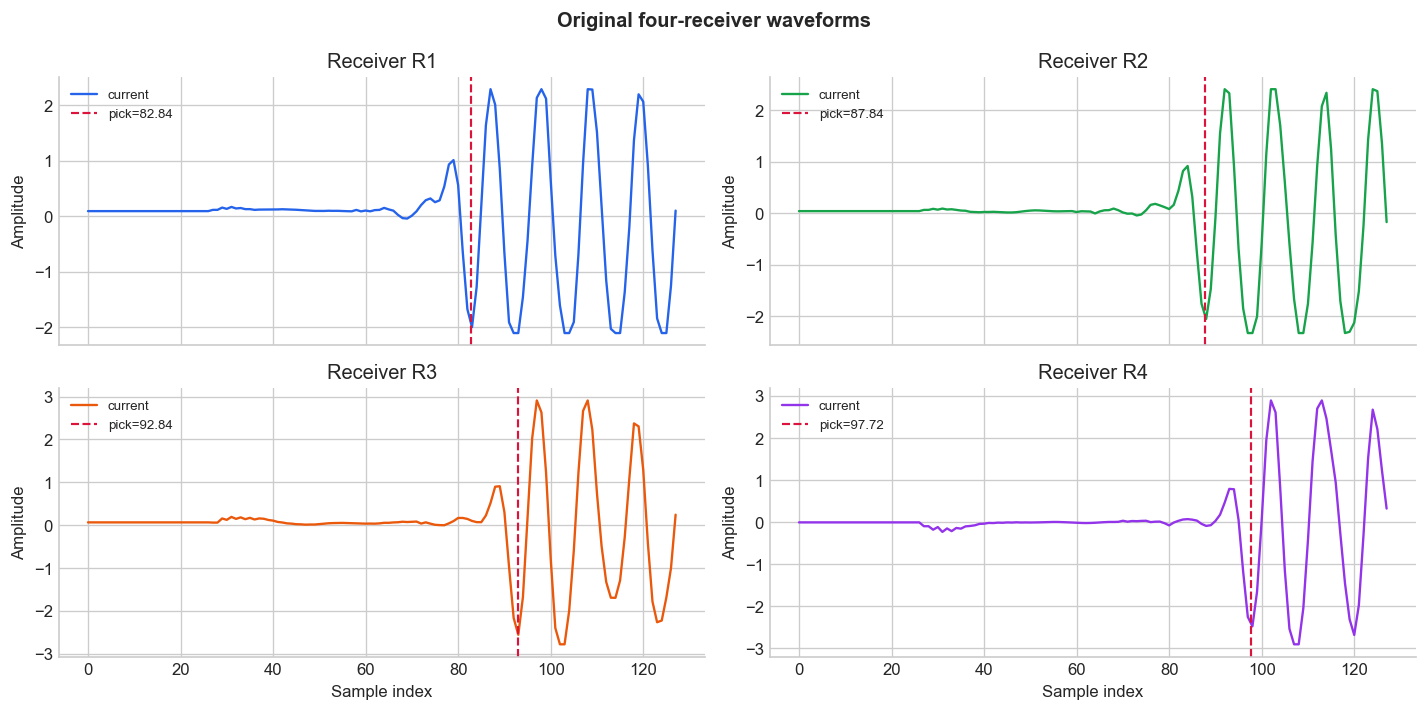

In [54]:
COLORS = ["#2563eb", "#16a34a", "#ea580c", "#9333ea"]

def plot_four(w, p, title, reference=None):
    fig, axes = plt.subplots(2, 2, figsize=(12, 6), sharex=True)
    x = np.arange(128)
    for ch, ax in enumerate(axes.flat):
        if reference is not None:
            ax.plot(x, reference[:, ch], color="0.65", lw=1.2, label="before")
        ax.plot(x, w[:, ch], color=COLORS[ch], lw=1.4, label="current")
        ax.axvline(p[ch], color="crimson", ls="--", lw=1.3,
                   label=f"pick={p[ch]:.2f}")
        ax.set_title(f"Receiver R{ch+1}"); ax.set_ylabel("Amplitude")
        ax.legend(fontsize=8, loc="upper left")
    axes[-1, 0].set_xlabel("Sample index"); axes[-1, 1].set_xlabel("Sample index")
    fig.suptitle(title, fontweight="bold"); fig.tight_layout()

plot_four(waveforms, picks, "Original four-receiver waveforms")
plt.show()

## 2. Two synthesis mechanisms

- **Global Temporal Translation:** uses the core implementation from `dif_time_g1.py`. For a left shift, the left boundary is truncated and the right boundary is extrapolated using the CWT-derived dominant frequency, Hilbert phase, five harmonics, and historical-value smoothing. For a right shift, the newly exposed samples at the left boundary are initialized to zero.
- **Differential Moveout Simulation:** uses the core implementation from `diff_velocity_g1.py`. R1 remains fixed, whereas R2--R4 are shifted by $0.5n$, $n$, and $1.5n$, respectively. The implementation performs 2x interpolation, CWT dominant-frequency estimation, boundary construction, resampling to 128 samples, smoothing of the first five samples, and three-point parabolic refinement of the picks.

Set the direction and displacement in the parameter cell through `GLOBAL_DIRECTION`, `GLOBAL_SHIFT_AMOUNT`, `MOVEOUT_DIRECTION`, and `MOVEOUT_STEP`.

In [10]:
def rebuild_masks_window(picks_samples):
    """Production-compatible one-hot masks for picks in sample units."""
    masks = np.zeros((picks_samples.shape[0], 1, 128, 4), dtype=np.float32)
    rounded = np.round(picks_samples).astype(int)
    for depth in range(picks_samples.shape[0]):
        for ch in range(4):
            if 0 <= rounded[depth, ch] < 128:
                masks[depth, 0, rounded[depth, ch], ch] = 1.0
    return masks

def run_global_translation_real(w_window, picks_norm, direction, amount):
    """Exact processing path from dif_time_g1.process_file_pair."""
    direction = direction.lower()
    if direction not in {"left", "right"}:
        raise ValueError("GLOBAL_DIRECTION must be 'left' or 'right'")
    if not isinstance(amount, (int, np.integer)) or amount <= 0:
        raise ValueError("GLOBAL_SHIFT_AMOUNT must be a positive integer")

    signal_length = w_window.shape[2]
    picks_samples = picks_norm.astype(float) * (signal_length - 1)
    center = picks_samples[w_window.shape[0] // 2]
    if direction == "left" and np.any(center <= amount):
        raise ValueError("Production boundary check failed: center pick <= left shift")
    if direction == "right" and np.any(center + amount >= 127):
        raise ValueError("Production boundary check failed: center pick + right shift >= 127")

    flat = w_window.transpose(0, 3, 1, 2).reshape(-1, signal_length)
    if direction == "left":
        shifted_flat = global_script.vectorized_shift_waveform_left(flat, amount)
        shifted_picks = np.maximum(0, picks_samples - amount)
    else:
        shifted_flat = global_script.vectorized_shift_waveform_right(flat, amount)
        shifted_picks = np.minimum(127, picks_samples + amount)
    shifted = shifted_flat.reshape(w_window.shape[0], 4, signal_length).transpose(0, 2, 1)
    shifted = shifted[:, np.newaxis, :, :].astype(np.float32)
    masks = rebuild_masks_window(shifted_picks)
    main_freqs = global_script.vectorized_analyze_time_frequency(
        w_window[DEPTH_INDEX, 0].T, global_script.SIGNAL_PARAMS)
    return shifted, shifted_picks, masks, main_freqs

def run_differential_moveout_real(w_window, picks_norm, direction, step):
    """Exact processing path from diff_velocity_g1.process_file_pair."""
    direction = direction.lower()
    if direction not in {"left", "right"}:
        raise ValueError("MOVEOUT_DIRECTION must be 'left' or 'right'")
    if not isinstance(step, (int, np.integer)) or step <= 0:
        raise ValueError("MOVEOUT_STEP must be a positive integer")
    is_left = direction == "left"
    if not moveout_script.check_data_validity(picks_norm[31], step, is_left):
        raise ValueError("Production moveout pre-screen failed at depth index 31")

    signed_steps = np.array([0, -step, -2*step, -3*step] if is_left
                            else [0, step, 2*step, 3*step], dtype=int)
    moved = w_window.copy()
    moved_picks = picks_norm.astype(float) * 127.0
    main_freqs = np.full((w_window.shape[0], 4), np.nan)
    for depth in range(w_window.shape[0]):
        for ch in range(1, 4):  # production script leaves R1 unchanged
            shifted_trace, main_freq = moveout_script.process_waveform(
                w_window[depth, 0, :, ch], int(signed_steps[ch]),
                moveout_script.SIGNAL_PARAMS)
            theoretical_pick = moved_picks[depth, ch]
            if is_left:
                theoretical_pick -= abs(signed_steps[ch]) * 0.5
            else:
                theoretical_pick += signed_steps[ch] * 0.5
            refined_pick = moveout_script.find_arrival_minimum(
                shifted_trace, theoretical_pick)
            moved[depth, 0, :, ch] = shifted_trace
            moved_picks[depth, ch] = refined_pick
            main_freqs[depth, ch] = main_freq
    masks = rebuild_masks_window(moved_picks)
    return moved, moved_picks, masks, signed_steps * 0.5, main_freqs

global_window_w, global_window_p, global_window_m, global_main_freqs = (
    run_global_translation_real(waveforms_all, picks_all, GLOBAL_DIRECTION,
                                GLOBAL_SHIFT_AMOUNT))
moveout_window_w, moveout_window_p, moveout_window_m, channel_shifts, moveout_main_freqs = (
    run_differential_moveout_real(waveforms_all, picks_all, MOVEOUT_DIRECTION,
                                  MOVEOUT_STEP))

global_w = global_window_w[DEPTH_INDEX, 0]
global_p = global_window_p[DEPTH_INDEX]
global_m = global_window_m[DEPTH_INDEX, 0]
moveout_w = moveout_window_w[DEPTH_INDEX, 0]
moveout_p = moveout_window_p[DEPTH_INDEX]
moveout_m = moveout_window_m[DEPTH_INDEX, 0]

display(pd.DataFrame({
    "receiver": ["R1", "R2", "R3", "R4"],
    "original_pick": picks, "global_pick": global_p,
    "moveout_shift": channel_shifts, "moveout_pick": moveout_p,
    "global_CWT_main_Hz": global_main_freqs,
}).round(3))

,receiver,original_pick,global_pick,moveout_shift,moveout_pick,global_CWT_main_Hz
0,R1,82.837,90.837,0.0,82.837,11363.636
1,R2,87.844,95.844,1.0,89.181,11363.636
2,R3,92.842,100.842,2.0,95.164,11363.636
3,R4,97.720,105.720,3.0,101.102,11363.636


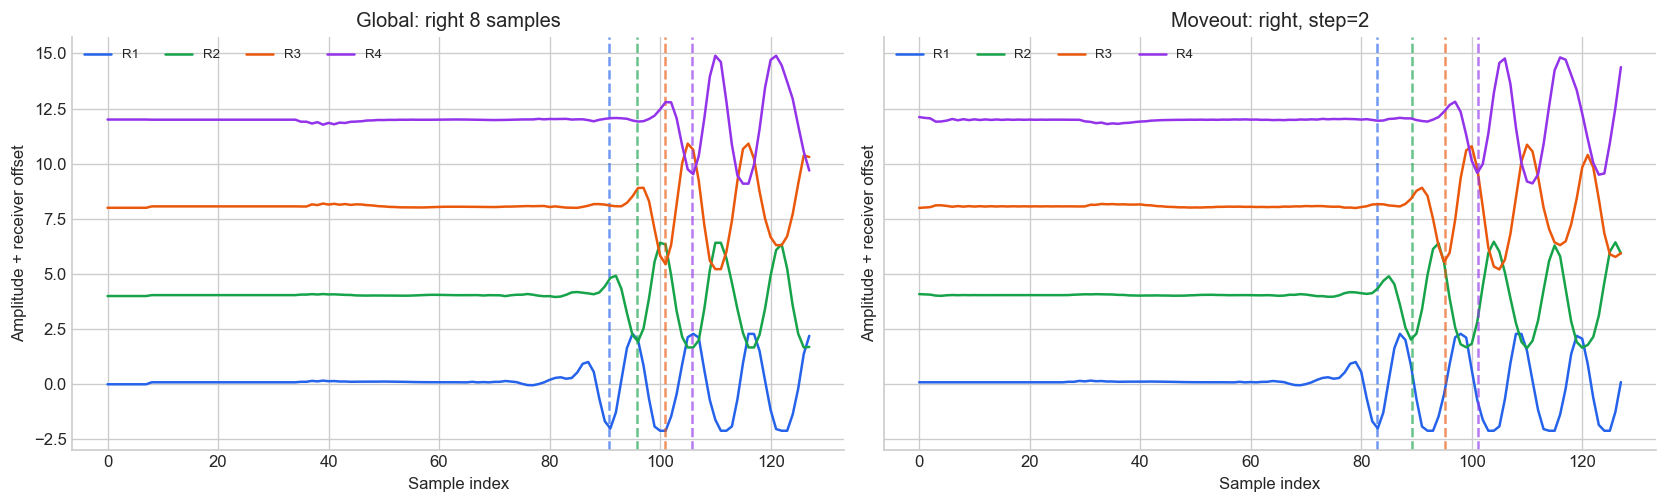

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.3), sharey=True)
x = np.arange(128)
for ch in range(4):
    offset = ch * 4
    axes[0].plot(x, global_w[:, ch] + offset, color=COLORS[ch], label=f"R{ch+1}")
    axes[0].axvline(global_p[ch], color=COLORS[ch], ls="--", alpha=.65)
    axes[1].plot(x, moveout_w[:, ch] + offset, color=COLORS[ch], label=f"R{ch+1}")
    axes[1].axvline(moveout_p[ch], color=COLORS[ch], ls="--", alpha=.65)
axes[0].set_title(f"Global: {GLOBAL_DIRECTION} {GLOBAL_SHIFT_AMOUNT} samples")
axes[1].set_title(f"Moveout: {MOVEOUT_DIRECTION}, step={MOVEOUT_STEP:g}")
for ax in axes:
    ax.set_xlabel("Sample index"); ax.set_ylabel("Amplitude + receiver offset")
    ax.legend(ncol=4, fontsize=8)
fig.tight_layout(); plt.show()

## 3. First screening

Calculate $\Delta_i=t_{i+1}-t_i$. Discard the sample if any $\Delta_i<0$, or if
$|\Delta_{i+1}-\Delta_i|>1$ sample.

In [12]:
def screening_metrics(p, max_second_difference=1.0):
    p = np.asarray(p, dtype=float)
    diffs = np.diff(p, axis=-1)
    changes = np.diff(diffs, axis=-1)
    valid = bool(np.all(diffs >= 0) and
                 np.all(np.abs(changes) <= max_second_difference))
    return diffs, changes, valid

def screening_row(name, p):
    d, c, valid = screening_metrics(p)
    return {"candidate": name, "Δ12": d[0], "Δ23": d[1], "Δ34": d[2],
            "Δ23-Δ12": c[0], "Δ34-Δ23": c[1], "selected_depth_pass": valid}

first_screen = pd.DataFrame([
    screening_row("Global translation", global_p),
    screening_row("Differential moveout", moveout_p)])
display(first_screen.round(3))

_, _, global_window_pass = screening_metrics(global_window_p)
_, _, moveout_window_pass = screening_metrics(moveout_window_p)
print({"Global — full 64-depth pass": global_window_pass,
       "Moveout — full 64-depth pass": moveout_window_pass})

,candidate,Δ12,Δ23,Δ34,Δ23-Δ12,Δ34-Δ23,selected_depth_pass
0,Global translation,5.008,4.997,4.878,-0.010,-0.120,True
1,Differential moveout,6.345,5.982,5.938,-0.362,-0.045,True


{'Global — full 64-depth pass': True, 'Moveout — full 64-depth pass': False}


## 4. Syn_1--Syn_4 augmentation

| Configuration | Effect |
|---|---|
| Syn_1 | Piecewise attenuation + sinusoidal baseline drift + scattering noise |
| Syn_2 | Stronger scattering noise |
| Syn_3 | Piecewise attenuation + weaker scattering noise |
| Syn_4 | Stronger piecewise attenuation |

The augmentation cell calls the embedded production `process_single_sample` function for each of the four configurations. Consequently, the enabled or disabled operations, attenuation intervals, noise regions, random ranges, and three-point parabolic label refinement remain identical to the source scripts. 

In [13]:
def run_real_augmentation(module, name, w_window, masks_window,
                                  picks_samples, seed=42):
    """Call the production module exactly, using one deterministic process."""
    random.seed(seed)
    np.random.seed(seed)
    result = module.process_single_sample((name, w_window.copy(),
                                           masks_window.copy(),
                                           (picks_samples / 127.0).astype(np.float32)))
    _, out_w, script_masks, out_picks_norm = result
    out_picks = out_picks_norm.astype(float) * 127.0
    rebuilt_masks = rebuild_masks_window(out_picks)
    return {
        "waveforms_full": out_w,
        "picks_full": out_picks,
        "script_masks_full": script_masks,
        "rebuilt_masks_full": rebuilt_masks,
    }

if global_window_pass:
    base_name = "Global translation"
    base_window_w, base_window_p, base_window_m = (
        global_window_w, global_window_p, global_window_m)
else:
    base_name = "Differential moveout"
    base_window_w, base_window_p, base_window_m = (
        moveout_window_w, moveout_window_p, moveout_window_m)

production_configs = {
    "Syn_1": syn1_script,
    "Syn_2": syn2_script,
    "Syn_3": syn3_script,
    "Syn_4": syn4_script,
}
configs = list(production_configs)
augmented_full = {
    name: run_real_augmentation(module, name, base_window_w, base_window_m,
                                base_window_p, seed=SEED)
    for name, module in production_configs.items()
}

base_w = base_window_w[DEPTH_INDEX, 0]
base_p = base_window_p[DEPTH_INDEX]
augmented = {
    name: (data["waveforms_full"][DEPTH_INDEX, 0],
           data["picks_full"][DEPTH_INDEX],
           data["script_masks_full"][DEPTH_INDEX, 0])
    for name, data in augmented_full.items()
}

parameter_table = pd.DataFrame([
    {"configuration": "Syn_1", "source": "enhance_data_g1.py",
     "enabled": "attenuation + curved drift + scattering",
     "noise_level": syn1_script.NOISE_PARAMS["noise_level"],
     "scatterers": syn1_script.NOISE_PARAMS["num_scatterers"]},
    {"configuration": "Syn_2", "source": "enhance_data_g2.py",
     "enabled": "scattering only",
     "noise_level": syn2_script.NOISE_PARAMS["noise_level"],
     "scatterers": syn2_script.NOISE_PARAMS["num_scatterers"]},
    {"configuration": "Syn_3", "source": "enhance_data_g3.py",
     "enabled": "attenuation + scattering",
     "noise_level": syn3_script.NOISE_PARAMS["noise_level"],
     "scatterers": syn3_script.NOISE_PARAMS["num_scatterers"]},
    {"configuration": "Syn_4", "source": "enhance_data_g4.py",
     "enabled": "attenuation only",
     "noise_level": 0.0, "scatterers": 0},
])
print("Common augmentation input:", base_name)
display(parameter_table)

Common augmentation input: Global translation


,configuration,source,enabled,noise_level,scatterers
0,Syn_1,enhance_data_g1.py,attenuation + curved drift + scattering,0.10,8
1,Syn_2,enhance_data_g2.py,scattering only,0.25,16
2,Syn_3,enhance_data_g3.py,attenuation + scattering,0.10,8
3,Syn_4,enhance_data_g4.py,attenuation only,0.00,0


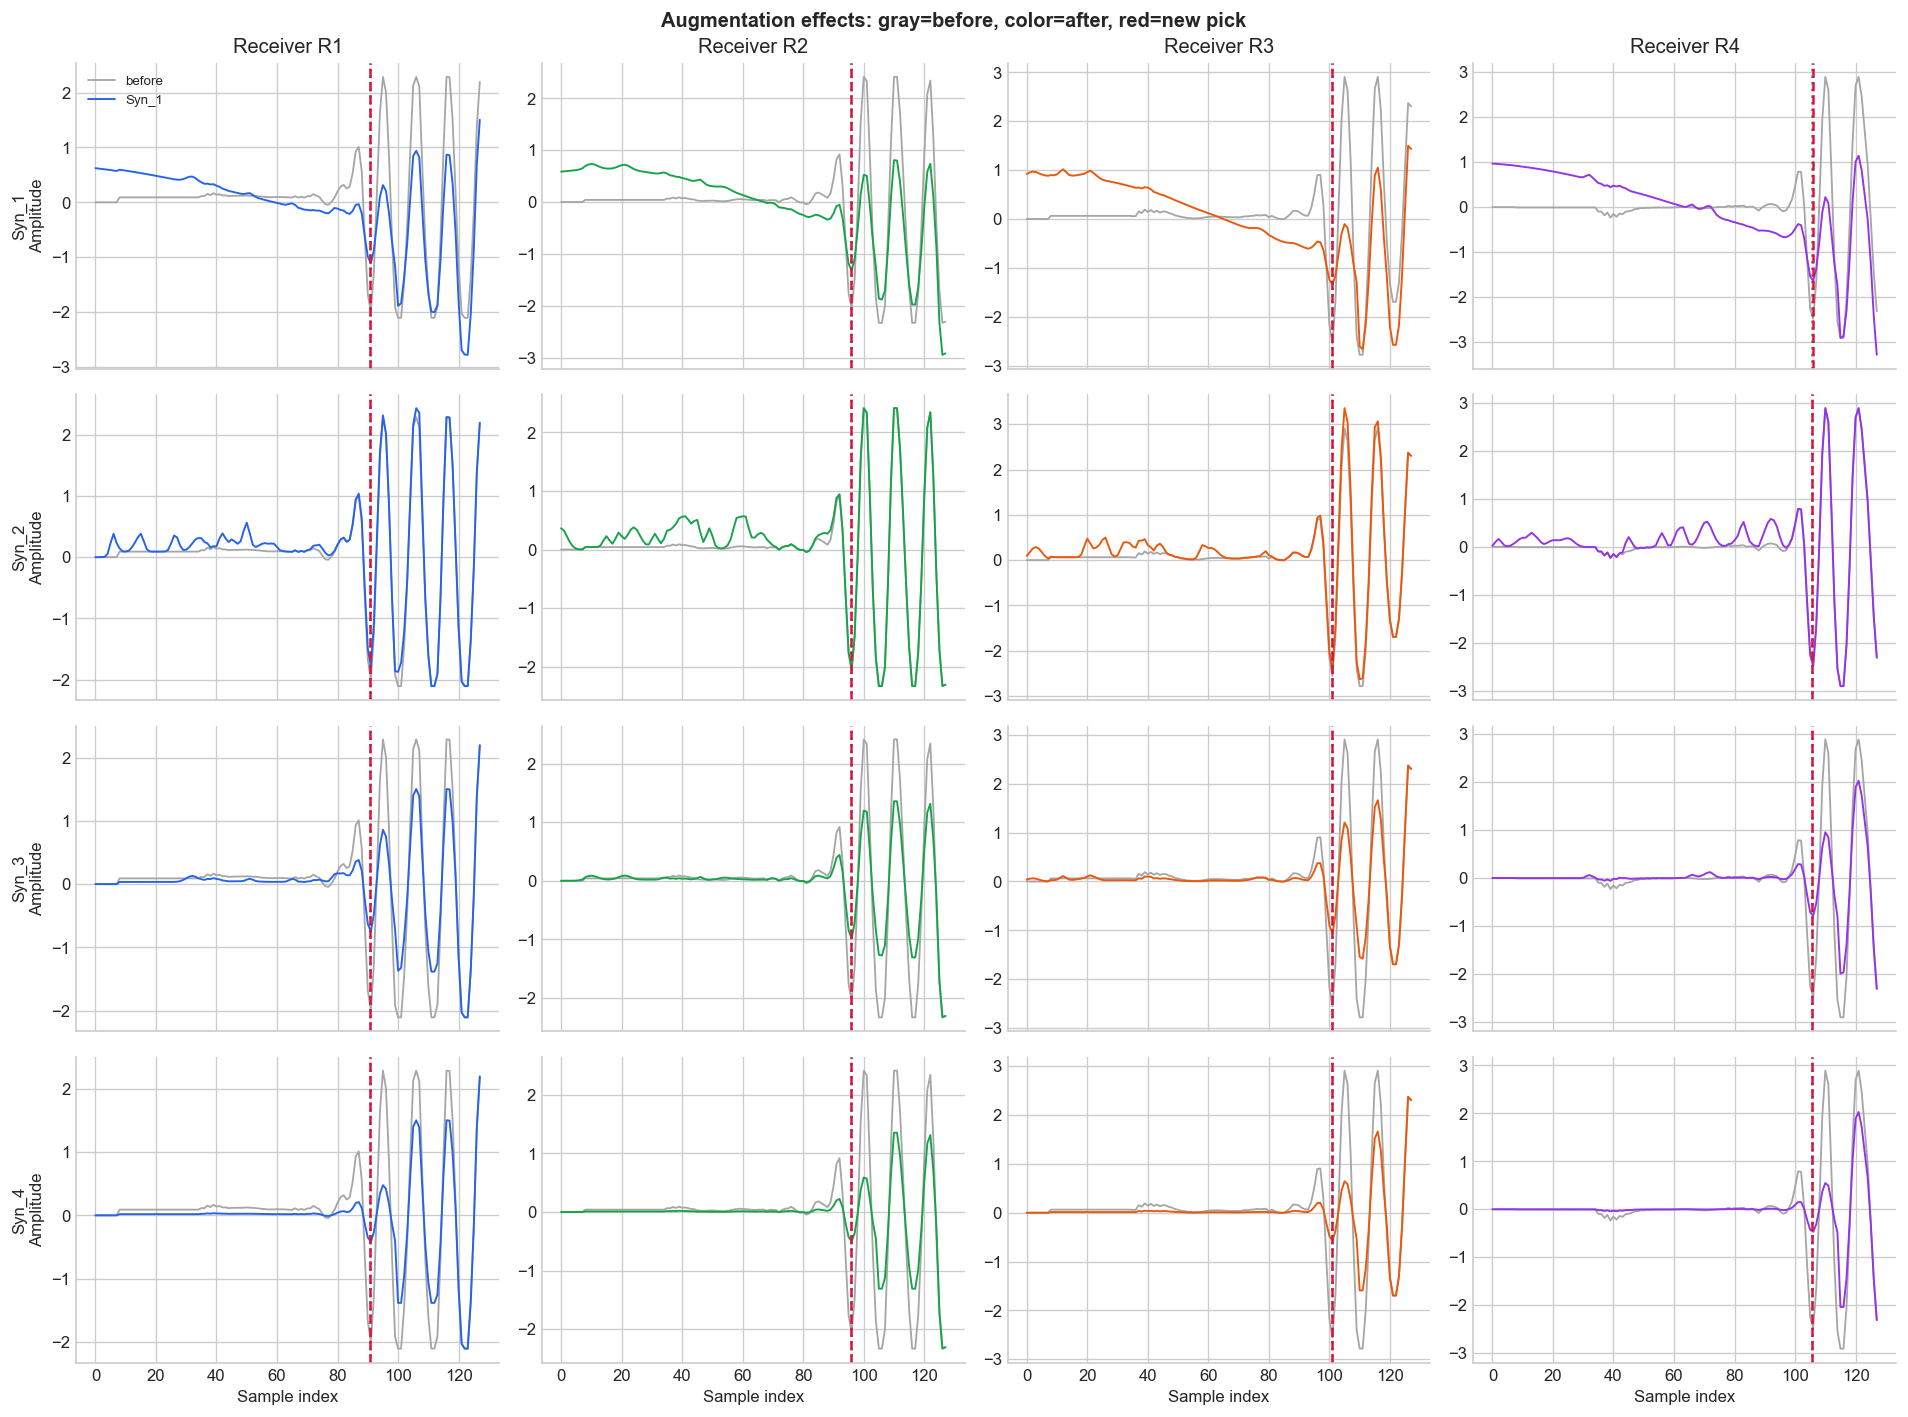

In [14]:
fig, axes = plt.subplots(4, 4, figsize=(16, 12), sharex=True)
x=np.arange(128)
for row, name in enumerate(configs):
    aug_w, aug_p, _ = augmented[name]
    for ch in range(4):
        ax=axes[row, ch]
        ax.plot(x, base_w[:, ch], color="0.65", lw=1.1, label="before")
        ax.plot(x, aug_w[:, ch], color=COLORS[ch], lw=1.15, label=name)
        ax.axvline(base_p[ch], color="0.45", ls=":")
        ax.axvline(aug_p[ch], color="crimson", ls="--")
        if row == 0: ax.set_title(f"Receiver R{ch+1}")
        if ch == 0: ax.set_ylabel(f"{name}\nAmplitude")
        if row == 3: ax.set_xlabel("Sample index")
        if row == 0 and ch == 0: ax.legend(fontsize=8)
fig.suptitle("Augmentation effects: gray=before, color=after, red=new pick",
             fontweight="bold")
fig.tight_layout(); plt.show()

## 5. Second screening and final result

After augmentation, recalculate the three adjacent inter-receiver arrival-time differences. Discard a sample if any difference exceeds `DELTA_MAX`; otherwise, retain it for the final training set.

`full-window geometry pass` evaluates the complete 64-depth window rather than only the displayed depth point. At every depth, it calculates
$\Delta_{12}=t_2-t_1$, $\Delta_{23}=t_3-t_2$, and $\Delta_{34}=t_4-t_3$. The result is `True` only when all 64 depths satisfy
$\Delta_i\geq0$, $|\Delta_{23}-\Delta_{12}|\leq1$, and $|\Delta_{34}-\Delta_{23}|\leq1$ sample.
If any depth violates a condition, the result is `False`. `full-window Δ ≤ δ_max` is a separate check.

In [15]:
final_rows=[]
for name in configs:
    aug_w, aug_p, aug_mask=augmented[name]
    d, c, _ = screening_metrics(aug_p)
    full_picks = augmented_full[name]["picks_full"]
    full_d, full_c, geometry_pass = screening_metrics(full_picks)
    delta_pass = bool(np.all(full_d <= DELTA_MAX))
    rebuilt_peak = augmented_full[name]["rebuilt_masks_full"][:, 0].argmax(axis=1)
    final_rows.append({"configuration": name, "Δ12": d[0], "Δ23": d[1],
        "Δ34": d[2], "max Δ": np.max(d), "nonnegative": np.all(d >= 0),
        "full-window geometry pass": geometry_pass,
        f"full-window Δ ≤ δ_max ({DELTA_MAX:g})": delta_pass,
        "added_to_D_train": geometry_pass and delta_pass})
final_screen=pd.DataFrame(final_rows); display(final_screen.round(3))

,configuration,Δ12,Δ23,Δ34,max Δ,nonnegative,full-window geometry pass,full-window Δ ≤ δ_max (12),added_to_D_train
0,Syn_1,5.009,5.010,4.884,5.010,True,True,True,True
1,Syn_2,5.016,4.978,4.898,5.016,True,False,True,False
2,Syn_3,5.006,5.000,4.886,5.006,True,False,True,False
3,Syn_4,5.008,4.998,4.878,5.008,True,True,True,True
